# EDA: Исследование корпуса данных

**Цель:** Исследовать датасет документов (Python-документация + ML-материалы), понять его структуру и подготовить к поиску.

**Используемые данные:** `data/ml_docs/` (7 файлов), `data/python_docs/` (7 файлов)

**Основные выводы:** (заполним в конце ноутбука)

---

## 1. Загрузка данных

In [1]:
import sys
import os

# Добавляем папку project в путь поиска модулей,
# чтобы Python нашёл наш src/data/loader.py
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data.loader import load_documents, load_and_chunk_documents

# Настройка графиков
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('Библиотеки загружены успешно')

Библиотеки загружены успешно


In [2]:
# Загружаем документы (запускаем из папки notebooks/,
# поэтому путь к data — '../data')
docs = load_documents('../data')
chunks = load_and_chunk_documents('../data')

print(f'Документов загружено: {len(docs)}')
print(f'Чанков создано: {len(chunks)}')

Документов загружено: 14
Чанков создано: 29


## 2. Общая статистика по документам

In [3]:
# Создаём DataFrame — таблицу с информацией о каждом документе
rows = []
for doc in docs:
    words = doc['text'].split()
    rows.append({
        'filename': doc['filename'],
        'category': doc['category'],
        'word_count': len(words),
        'char_count': len(doc['text']),
        'line_count': len(doc['text'].splitlines()),
    })

df = pd.DataFrame(rows)
df

,filename,category,word_count,char_count,line_count
0,classification.txt,ml_docs,216,1750,33
1,embeddings.txt,ml_docs,269,2153,46
2,neural_networks.txt,ml_docs,287,2014,42
3,overfitting.txt,ml_docs,196,1453,28
4,regression.txt,ml_docs,201,1614,34
5,train_test_split.txt,ml_docs,253,1899,39
6,underfitting.txt,ml_docs,186,1410,29
7,os_path.txt,python_docs,232,2028,69
8,string_methods.txt,python_docs,278,1969,70
9,classes.txt,python_docs,255,2085,80


In [4]:
# Общая статистика
print('=== Статистика по категориям ===')
print(df.groupby('category')['word_count'].agg(['count', 'sum', 'mean', 'min', 'max']).round(1))
print()
print(f'Всего слов в корпусе: {df["word_count"].sum()}')
print(f'Среднее слов на документ: {df["word_count"].mean():.1f}')

=== Статистика по категориям ===
             count   sum   mean  min  max
category                                 
ml_docs          7  1608  229.7  186  287
python_docs      7  1840  262.9  232  317

Всего слов в корпусе: 3448
Среднее слов на документ: 246.3


## 3. Визуализация: количество слов по документам

In [5]:
for doc in docs:
    if doc["category"] == "other":
        print(doc["source"])

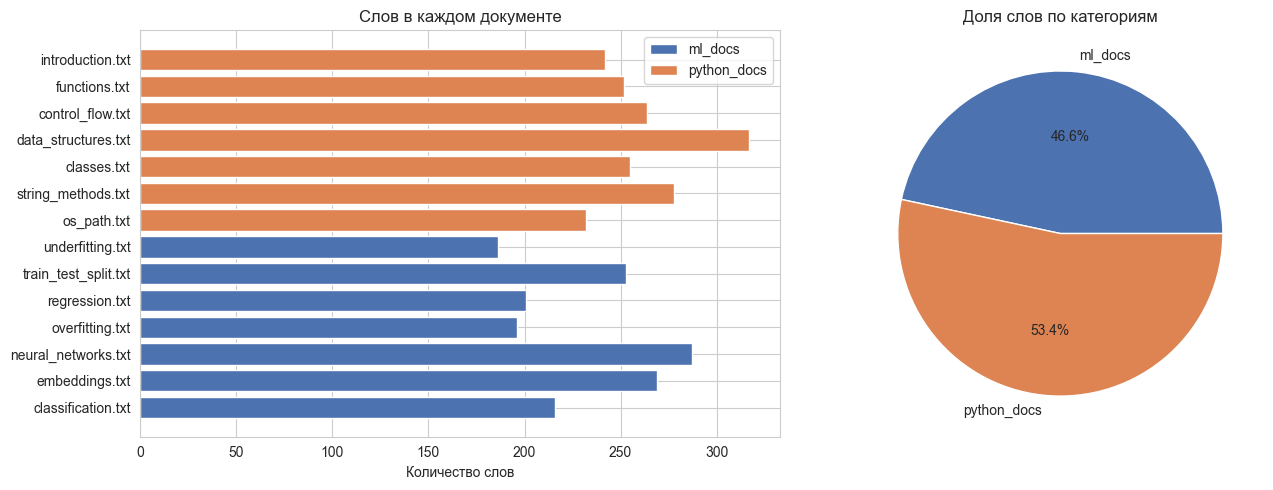

График сохранён в artifacts/eda_word_counts.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество слов в каждом документе
colors = df['category'].map({'ml_docs': '#4C72B0', 'python_docs': '#DD8452'})
axes[0].barh(df['filename'], df['word_count'], color=colors)
axes[0].set_xlabel('Количество слов')
axes[0].set_title('Слов в каждом документе')

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='ml_docs'),
    Patch(facecolor='#DD8452', label='python_docs')
]
axes[0].legend(handles=legend_elements)

# График 2: Распределение по категориям (pie chart)
category_words = df.groupby('category')['word_count'].sum()
axes[1].pie(
    category_words,
    labels=category_words.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452']
)
axes[1].set_title('Доля слов по категориям')

plt.tight_layout()
plt.savefig('../artifacts/eda_word_counts.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён в artifacts/eda_word_counts.png')

## 4. Анализ чанков

In [7]:
# Информация о чанках
chunk_rows = []
for chunk in chunks:
    chunk_rows.append({
        'filename': chunk['filename'],
        'category': chunk['category'],
        'chunk_id': chunk['chunk_id'],
        'word_count': len(chunk['text'].split()),
    })

df_chunks = pd.DataFrame(chunk_rows)

print(f'Всего чанков: {len(df_chunks)}')
print(f'Среднее слов в чанке: {df_chunks["word_count"].mean():.1f}')
print(f'Минимум слов в чанке: {df_chunks["word_count"].min()}')
print(f'Максимум слов в чанке: {df_chunks["word_count"].max()}')
print()
print('Чанков по категориям:')
print(df_chunks['category'].value_counts())

Всего чанков: 29
Среднее слов в чанке: 143.0
Минимум слов в чанке: 17
Максимум слов в чанке: 200

Чанков по категориям:
category
python_docs    15
ml_docs        14
Name: count, dtype: int64


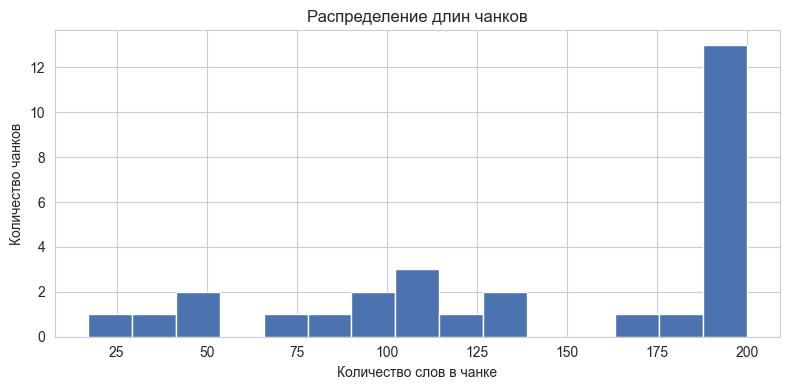

График сохранён в artifacts/eda_chunk_distribution.png


In [8]:
# Гистограмма длин чанков
plt.figure(figsize=(8, 4))
plt.hist(df_chunks['word_count'], bins=15, color='#4C72B0', edgecolor='white')
plt.xlabel('Количество слов в чанке')
plt.ylabel('Количество чанков')
plt.title('Распределение длин чанков')
plt.tight_layout()
plt.savefig('../artifacts/eda_chunk_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён в artifacts/eda_chunk_distribution.png')

## 5. Самые частые слова

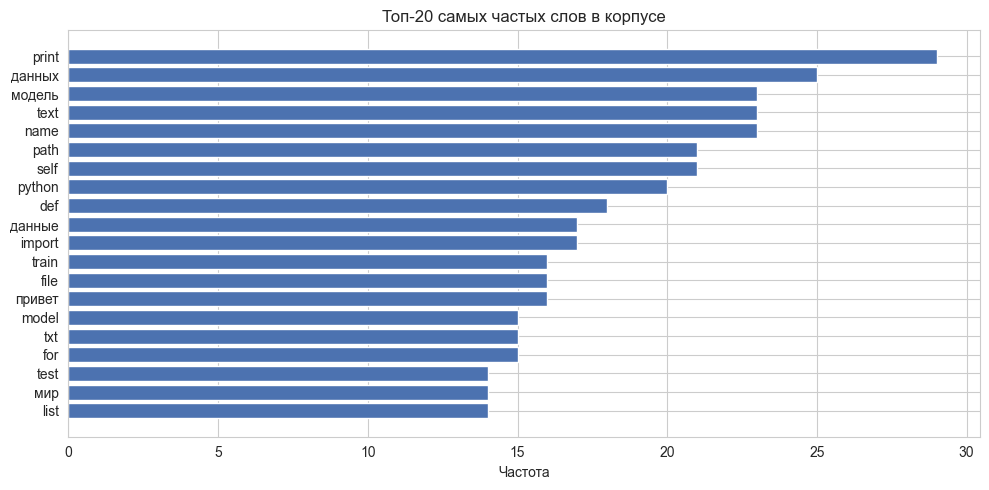

График сохранён в artifacts/eda_top_words.png


In [9]:
# Объединяем весь текст и считаем частоту слов
# Стоп-слова — слова которые не несут смысла (предлоги, союзы и т.д.)
stop_words = {
    'и', 'в', 'на', 'с', 'по', 'для', 'от', 'к', 'или', 'что', 'это',
    'как', 'не', 'а', 'но', 'если', 'то', 'из', 'при', 'за', 'о',
    'так', 'же', 'чем', 'до', 'из', 'у', 'об', 'без', 'при', 'через',
    'когда', 'где', 'все', 'всё', 'нет', 'есть', 'быть', 'его', 'её',
    'он', 'она', 'они', 'мы', 'вы', 'я', 'их', 'им', 'ему', 'ей',
    'чтобы', 'также', 'которые', 'которая', 'который', 'которое',
    'между', 'этот', 'эта', 'эти', 'этих', 'тем', 'те', 'той', 'том',
}

all_text = ' '.join(doc['text'] for doc in docs).lower()
# Убираем знаки препинания
import re
words_only = re.findall(r'[а-яёa-z]+', all_text)
# Фильтруем стоп-слова и очень короткие слова
filtered = [w for w in words_only if w not in stop_words and len(w) > 2]

top_words = Counter(filtered).most_common(20)

# Строим график
words_list, counts_list = zip(*top_words)
plt.figure(figsize=(10, 5))
plt.barh(list(reversed(words_list)), list(reversed(counts_list)), color='#4C72B0')
plt.xlabel('Частота')
plt.title('Топ-20 самых частых слов в корпусе')
plt.tight_layout()
plt.savefig('../artifacts/eda_top_words.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён в artifacts/eda_top_words.png')

## 6. Примеры чанков

In [10]:
# Посмотрим на несколько чанков — убедимся что разбиение выглядит нормально
print('=== Примеры чанков ===')
for i, chunk in enumerate(chunks[:3]):
    print(f'\n--- Чанк {i} [{chunk["category"]}] {chunk["filename"]} ---')
    print(chunk['text'][:250] + '...')

=== Примеры чанков ===

--- Чанк 0 [ml_docs] classification.txt ---
Классификация (Classification) Классификация — задача машинного обучения, в которой нужно предсказать категорию (класс) объекта. Например: спам/не спам, кошка/собака, болен/здоров. Типы классификации: - Бинарная (Binary) — два класса: да/нет, 0/1. - ...

--- Чанк 1 [ml_docs] classification.txt ---
(полнота) — из всех реальных положительных, сколько мы нашли. - F1-score — гармоническое среднее Precision и Recall. Баланс между ними. - ROC-AUC — площадь под кривой ROC. Чем ближе к 1, тем лучше. - Confusion Matrix — матрица ошибок: TP, TN, FP, FN....

--- Чанк 2 [ml_docs] embeddings.txt ---
Эмбеддинги (Embeddings) Эмбеддинги — это числовые представления объектов (слов, предложений, документов) в виде векторов в многомерном пространстве. Близкие по смыслу объекты имеют близкие векторы. Зачем нужны эмбеддинги: Компьютер не понимает текст ...


## 7. Выводы

По результатам EDA:

- **Всего документов:** 14 (7 ML + 7 Python)
- **Средняя длина документа:** ~250 слов
- **Всего чанков** при chunk_size=200, overlap=50: ~29
- **Данные качественные:** текст чистый, структурированный, без шума
- **Тематика корпуса** хорошо видна в топ-словах: модель, данные, обучение, python, функция

**Следующий шаг:** реализация TF-IDF поиска по этим чанкам.